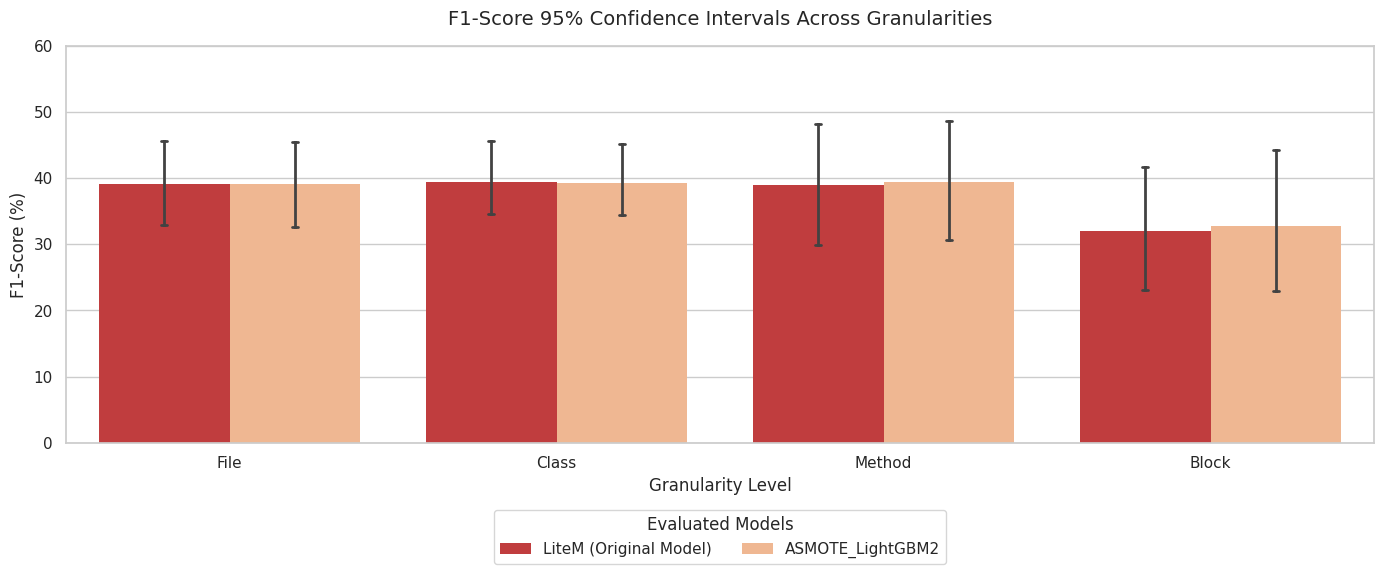

In [7]:
import glob
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Label_idx = 2 is f1-score
METRIC_IDX = 2

METRICS = ["Precision", "Recall", "F1-Score", "AUC", "MCC"]
METRIC = METRICS[METRIC_IDX]


FILE_PREFIX = "within_project_"
FOLDER_PATH = "../results/removing_duplicates_on_test/"

# =====================================================================
# STEP 1: READ THE DATA
# =====================================================================


def clean_cell(text):
    """Removes LaTeX specific formatting elements."""
    text = re.sub(r"\\textbf\{([^}]+)\}", r"\1", text)
    text = re.sub(r"\\[a-zA-Z]+", "", text)
    return text.replace("\\", "").replace("%", "").strip()


def parse_file_metrics(filepath):
    """Parses a file, normalizes decimal/percentage formats, and drops averages."""
    rows = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or "&" not in line:
                continue

            parts = [clean_cell(p) for p in line.split("&")]
            if len(parts) < 21:
                continue

            if parts[0].lower() == "average":
                continue

            try:
                
                # Corrected indices for F1-score: 3, 8, 13, 18
                # So the idx must be LABEL_IDX + 1
                raw_file = float(parts[METRIC_IDX + 1 + 5 * 0])
                raw_class = float(parts[METRIC_IDX + 1 + 5 * 1])
                raw_method = float(parts[METRIC_IDX + 1 + 5 * 2])
                raw_block = float(parts[METRIC_IDX + 1 + 5 * 3])

                # Normalize everything to a 0-100% scale
                # If a value is <= 1.0 (and not explicitly 0), it's treated as a decimal
                file_metric = raw_file * 100 if 0 < raw_file <= 1.0 else raw_file
                class_metric = raw_class * 100 if 0 < raw_class <= 1.0 else raw_class
                method_metric = (
                    raw_method * 100 if 0 < raw_method <= 1.0 else raw_method
                )
                block_metric = (
                    raw_block * 100 if 0 < raw_block <= 1.0 else raw_block
                )

                rows.append(
                    {
                        "Project": parts[0],
                        "File": file_metric,
                        "Class": class_metric,
                        "Method": method_metric,
                        "Block": block_metric,
                    }
                )
            except ValueError:
                continue
    return pd.DataFrame(rows)



def load_all_models(prefix="within_project_"):
    """Discovers files and pairs model names with their extracted dataframes."""
    datasets = {}
    search_path = os.path.join(FOLDER_PATH, f"{prefix}*")
    for filepath in glob.glob(search_path):
        filename = os.path.basename(filepath)
        model_name = filename.replace(prefix, "").replace(".txt", "")

        df = parse_file_metrics(filepath)
        if not df.empty:
            datasets[model_name] = df
    return datasets

# =====================================================================
# STEP 2: RESTRUCTURE FOR COMPREHENSIVE VISUALIZATION
# =====================================================================


def build_comparison_dataset(datasets):
    """Converts independent wide dataframes into a master unified dataset."""
    compiled_frames = []

    for model_name, df in datasets.items():
        melted_df = df.melt(
            id_vars=["Project"],
            value_vars=["File", "Class", "Method", "Block"],
            var_name="Granularity",
            value_name=METRIC,
        )
        melted_df["Model"] = model_name
        compiled_frames.append(melted_df)

    return (
        pd.concat(compiled_frames, ignore_index=True)
        if compiled_frames
        else pd.DataFrame()
    )


# =====================================================================
# STEP 3: PLOT THE COMPREHENSIVE COMPARISON
# =====================================================================
def plot_model_comparison(comparison_df):
    if comparison_df.empty:
        return

    # Keep the plot wide to give the 11 bars room
    plt.figure(figsize=(14, 6))
    sns.set_theme(style="whitegrid")

    unique_models = list(comparison_df["Model"].unique())

    base_colors = sns.color_palette("pastel", len(unique_models))
    custom_palette = {
        model: color for model, color in zip(unique_models, base_colors)
    }
    custom_palette["LiteM (Original Model)"] = "#d62728"  # Your bold crimson highlight

    sns.barplot(
        data=comparison_df,
        x="Granularity",
        y=METRIC,
        hue="Model",
        hue_order=unique_models,  # 1. Aligns visual bar order with legend order
        errorbar="ci",
        capsize=0.04,
        edgecolor="none",
        palette=custom_palette,
        err_kws={"linewidth": 2},  # 2. Makes the CI whiskers thicker and clearer
    )

    plt.ylim(0, 60)
    plt.title(
        "F1-Score 95% Confidence Intervals Across Granularities",
        fontsize=14,
        pad=15,
    )
    plt.ylabel("F1-Score (%)", fontsize=12)
    plt.xlabel("Granularity Level", fontsize=12)

    # 3. Placed below the chart in 3 columns so the main plot can expand horizontally
    plt.legend(
        title="Evaluated Models",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
    )

    plt.tight_layout()
    plt.show()

# =====================================================================
# MAIN RUNNER
# =====================================================================
if __name__ == "__main__":
    # Module 1: Extract
    raw_data = load_all_models()

    # Module 2: Transform
    master_df = build_comparison_dataset(raw_data)

    master_df.Model = master_df.Model.replace("ASMOTE_LightGBM", "LiteM (Original Model)")

    # Module 3: Visualize
    plot_model_comparison(master_df)

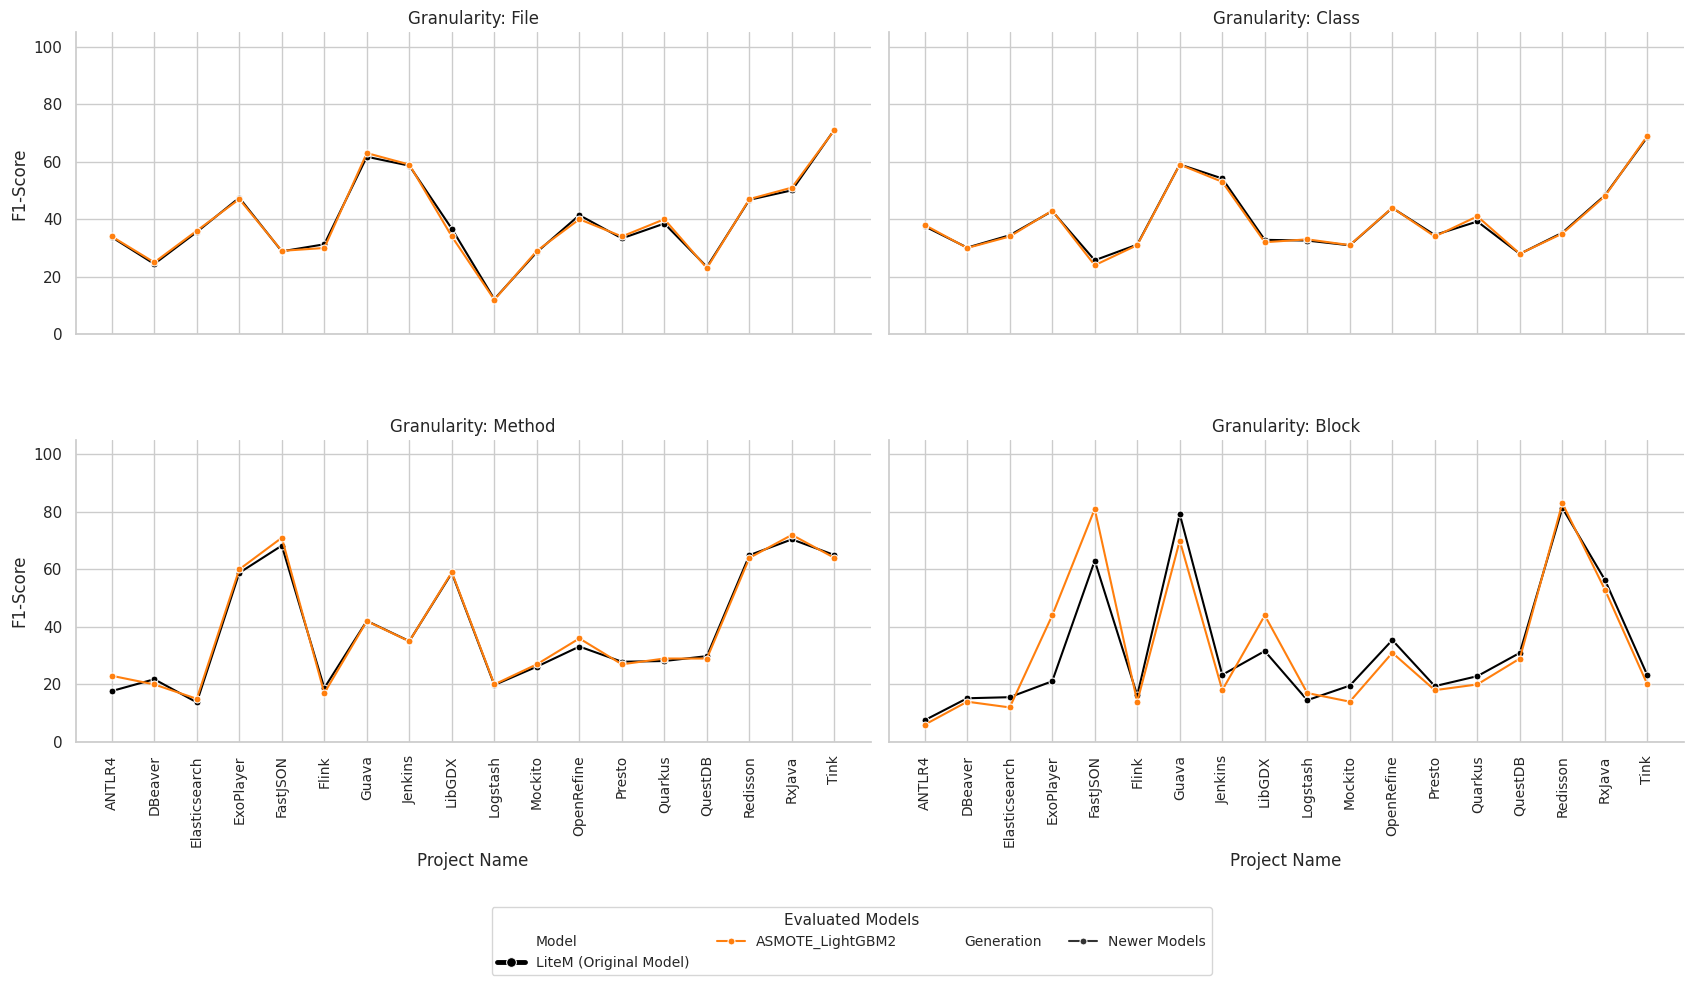

In [13]:
# =====================================================================
# STEP 3: PLOTTING FUNCTION (FIXED & ROBUST)
# =====================================================================

import matplotlib.pyplot as plt
import seaborn as sns


def plot_granularity_line_charts(comparison_df):
    """Plots a 2x2 grid of line charts, segregating models by generation

    and highlighting the LiteM model.
    """
    if comparison_df.empty:
        print("No processed data found to generate plots.")
        return

    # 1. Define model groupings
    newer_models = [
        "LiteM (Original Model)",
        "ADASYN_LightGBM",
        "SMOTE_LightGBM",
        "ENN_LightGBM",
        "NoSMOTE_LightGBM",
        "ASMOTE_XGB",
        "ASMOTE_LogisticRegression",
        "ASMOTE_RF",
        "ASMOTE_DecisionTree",
        "ASMOTE_Ridge",
        "ASMOTE_ET",
        "ASMOTE_NaiveBayes",
        "ASMOTE_LDA",
        "TL_LightGBM",
        "RUS_LightGBM",
        "ASMOTE_LightGBM2"
    ]

    old_school_models = [
        "ASMOTE_LogisticRegression",
        "ASMOTE_DecisionTree",
        "ASMOTE_NaiveBayes",
        "ASMOTE_Ridge",
        "ASMOTE_LDA",
    ]

    # 2. Add segregation column to the DataFrame
    def categorize_generation(model):
        if model in newer_models:
            return "Newer Models"
        elif model in old_school_models:
            return "Old School Models"
        return "Other"

    # Avoid SettingWithCopyWarning
    comparison_df = comparison_df.copy()
    comparison_df["Generation"] = comparison_df["Model"].apply(
        categorize_generation
    )

    # 3. Create a dynamic palette ensuring all present models have colors
    unique_models = comparison_df["Model"].unique()
    colors = sns.color_palette("tab10", n_colors=len(unique_models))
    custom_palette = {model: color for model, color in zip(unique_models, colors)}

    # Always override LiteM to Jet Black
    if "LiteM (Original Model)" in custom_palette:
        custom_palette["LiteM (Original Model)"] = "#000000"

    sns.set_theme(style="whitegrid")
    granularity_order = ["File", "Class", "Method", "Block"]

    # Explicitly pull unique models present in data to maintain clean legend order
    model_order = [m for m in newer_models if m in unique_models] + [
        m for m in old_school_models if m in unique_models
    ]

    g = sns.FacetGrid(
        data=comparison_df,
        col="Granularity",
        col_wrap=2,
        height=5,
        aspect=1.7,
        col_order=granularity_order,
        sharey=True,
    )

    # 4. Map lineplot using both 'hue' (colors) and 'style' (solid vs dashed generations)
    g.map_dataframe(
        sns.lineplot,
        x="Project",
        y=METRIC,
        hue="Model",
        hue_order=model_order if model_order else None,
        style="Generation",
        palette=custom_palette,
        marker="o",
        markersize=5,
        linewidth=1.5,
    )

    g.set_axis_labels("", "")

    # 5. Format axes, labels, and thicken LiteM line
    for ax_idx, ax in enumerate(g.axes.flat):
        if ax_idx >= 2:
            ax.set_xlabel("Project Name", fontsize=12)

        granularity = granularity_order[ax_idx]
        ax.set_title(f"Granularity: {granularity}", fontsize=12)

        # Fix overlapping x-tick text safely without warnings
        ax.tick_params(axis="x", rotation=90, labelsize=10)

        # Thicken LiteM line on canvas
        for line in ax.lines:
            if line.get_label() == "LiteM (Original Model)":
                line.set_linewidth(3.5)
                line.set_markersize(7)
                line.set_zorder(10)  # Bring to front

    g.axes.flat[0].set_ylabel(METRIC, fontsize=12)
    g.axes.flat[2].set_ylabel(METRIC, fontsize=12)
    g.set(ylim=(0, 105))

    # 6. Formatting & Legend Layout
    plt.subplots_adjust(bottom=0.25, hspace=0.35)

    handles, labels = g.axes.flat[0].get_legend_handles_labels()

    g.fig.legend(
        handles=handles,
        labels=labels,
        title="Evaluated Models",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=4,
        fontsize=10,
        title_fontsize=11,
    )

    # 7. Save & Show Plot
    plt.savefig(
        "/home/mignoe/Documents/git/Dataset4TD/Miguel/plots/output.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


# =====================================================================
# MAIN RUNNER
# =====================================================================
if __name__ == "__main__":
    # Ensure helper functions exist before running
    raw_projects = load_all_models(prefix=FILE_PREFIX)

    if not raw_projects:
        print(
            f"No matching data files found in '{FOLDER_PATH}' with prefix '{FILE_PREFIX}'"
        )
    else:
        prepared_df = build_comparison_dataset(raw_projects)
        prepared_df["Model"] = prepared_df["Model"].replace(
            "ASMOTE_LightGBM", "LiteM (Original Model)"
        )

        plot_granularity_line_charts(prepared_df)

In [9]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def generate_interactive_granularity_chart(
    comparison_df, output_path="model_comparison.html"
):
    """Generates a standalone, interactive Plotly HTML dashboard for model comparison across granularities."""
    if comparison_df.empty:
        print("No processed data found to generate plots.")
        return

    # 1. Clean Data & Map Categories
    comparison_df = comparison_df.copy()

    newer_models = [
        "LiteM (Original Model)",
        "ADASYN_LightGBM",
        "SMOTE_LightGBM",
        "ENN_LightGBM",
        "NoSMOTE_LightGBM",
        "ASMOTE_XGB",
        "ASMOTE_LogisticRegression",
        "ASMOTE_RF",
        "ASMOTE_DecisionTree",
        "ASMOTE_Ridge",
        "ASMOTE_ET",
        "ASMOTE_NaiveBayes",
        "ASMOTE_LDA",
        "TL_LightGBM",
        "RUS_LightGBM",
    ]

    old_school_models = [
        "ASMOTE_LogisticRegression",
        "ASMOTE_DecisionTree",
        "ASMOTE_NaiveBayes",
        "ASMOTE_Ridge",
        "ASMOTE_LDA",
    ]

    def categorize_generation(model):
        if model in newer_models:
            return "Newer Models"
        elif model in old_school_models:
            return "Old School Models"
        return "Other"

    comparison_df["Generation"] = comparison_df["Model"].apply(
        categorize_generation
    )

    granularity_order = ["File", "Class", "Method", "Block"]
    unique_models = comparison_df["Model"].unique()

    # 2. Assign Color Palette (Highlight LiteM in Black)
    color_palette = px.colors.qualitative.Alphabet
    model_colors = {
        model: color_palette[i % len(color_palette)]
        for i, model in enumerate(unique_models)
    }
    if "LiteM (Original Model)" in model_colors:
        model_colors["LiteM (Original Model)"] = "#000000"

    # 3. Create 2x2 Subplot Grid
    fig = make_subplots(
        rows=2,
        cols=2,
        subplot_titles=[
            f"Granularity: {g}" for g in granularity_order
        ],
        shared_xaxes=True,
        shared_yaxes=True,
        vertical_spacing=0.12,
        horizontal_spacing=0.05,
    )

    grid_map = {
        "File": (1, 1),
        "Class": (1, 2),
        "Method": (2, 1),
        "Block": (2, 2),
    }

    # Track visible legends to prevent duplicate legend entries
    added_to_legend = set()

    # 4. Add Traces for Each Model and Granularity
    for granularity in granularity_order:
        row, col = grid_map[granularity]
        sub_df = comparison_df[comparison_df["Granularity"] == granularity]

        for model in unique_models:
            model_df = sub_df[sub_df["Model"] == model]
            if model_df.empty:
                continue

            is_litem = model == "LiteM (Original Model)"
            show_legend = model not in added_to_legend
            if show_legend:
                added_to_legend.add(model)

            # Dash line for Old School models, Solid for Newer
            gen = model_df["Generation"].iloc[0]
            dash_style = "dash" if gen == "Old School Models" else "solid"

            fig.add_trace(
                go.Scatter(
                    x=model_df["Project"],
                    y=model_df[METRIC],
                    mode="lines+markers",
                    name=model,
                    legendgroup=model,  # Toggles all 4 subplots simultaneously on click
                    showlegend=show_legend,
                    line=dict(
                        color=model_colors[model],
                        width=3.5 if is_litem else 1.5,
                        dash=dash_style,
                    ),
                    marker=dict(size=7 if is_litem else 5),
                    hovertemplate=(
                        f"<b>Model:</b> {model}<br>"
                        "<b>Project:</b> %{x}<br>"
                        "<b>F1-Score:</b> %{y:.2f}%<extra></extra>"
                    ),
                ),
                row=row,
                col=col,
            )

    # 5. Styling Layout & Interactivity
    fig.update_layout(
        title={
            "text": "Model Performance Across Granularities",
            "x": 0.5,
            "xanchor": "center",
            "font": {"size": 20},
        },
        template="plotly_white",
        height=850,
        legend=dict(
            title="Models (Click to filter)",
            orientation="h",
            y=-0.15,
            x=0.5,
            xanchor="center",
            font=dict(size=10),
        ),
        margin=dict(l=60, r=40, t=80, b=120),
    )

    # Set Axes Labels and Rotation
  
    fig.update_yaxes(title_text=METRIC, range=[0, 105], row=1, col=1)
    fig.update_yaxes(title_text=METRIC, range=[0, 105], row=2, col=1)
    fig.update_xaxes(tickangle=-45, row=2, col=1)
    fig.update_xaxes(tickangle=-45, row=2, col=2)

    # Save to Standalone HTML File
    fig.write_html(output_path, include_plotlyjs="cdn")
    print(f"Interactive dashboard successfully saved to: {output_path}")


# =====================================================================
# MAIN RUNNER EXAMPLE
# =====================================================================
if __name__ == "__main__":
    raw_projects = load_all_models(prefix=FILE_PREFIX)

    if not raw_projects:
        print(
            f"No matching data files found in '{FOLDER_PATH}' with prefix '{FILE_PREFIX}'"
        )
    else:
        prepared_df = build_comparison_dataset(raw_projects)
        prepared_df["Model"] = prepared_df["Model"].replace(
            "ASMOTE_LightGBM", "LiteM (Original Model)"
        )

        generate_interactive_granularity_chart(
            prepared_df,
            output_path=f"/home/mignoe/Documents/git/Dataset4TD/Miguel/plots/interactive_output_{METRIC}.html",
        )

Interactive dashboard successfully saved to: /home/mignoe/Documents/git/Dataset4TD/Miguel/plots/interactive_output_F1-Score.html


In [10]:
!pip install plotly


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [11]:
prepared_df.Model.unique()

<StringArray>
['LiteM (Original Model)', 'ASMOTE_LightGBM2']
Length: 2, dtype: str

ValueError: Could not interpret value `F1_Score` for `y`. An entry with this name does not appear in `data`.

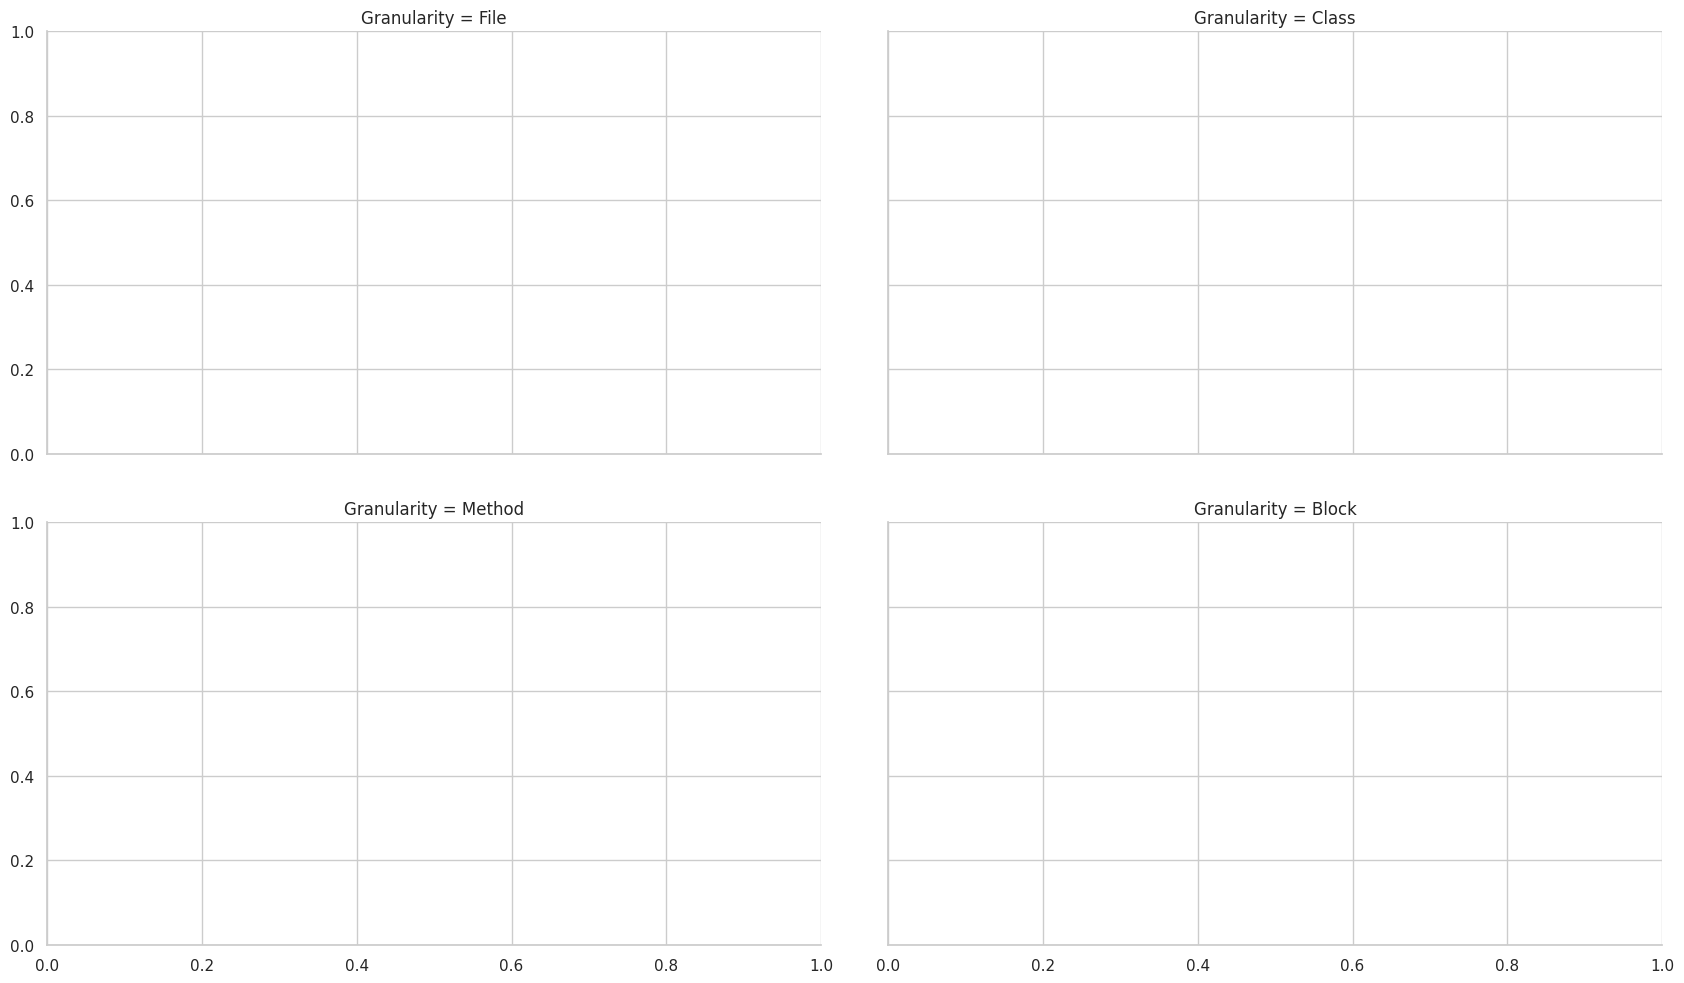

In [12]:
# =====================================================================
# STEP 3: PLOTTING FUNCTION BETTER VISUALIZATION
# =====================================================================


import matplotlib.pyplot as plt
import seaborn as sns


def plot_granularity_line_charts(comparison_df):
    """Plots a 2x2 grid of line charts, segregating models by generation

    and highlighting the LiteM model.
    """
    if comparison_df.empty:
        print("No processed data found to generate plots.")
        return

    # 1. Define model groupings
    newer_models = [
        "LiteM (Original Model)",
        "ENN_ET",
        "ENN_LightGBM",
        "ENN_MLP",
        "ASMOTE_RF",
        "ASMOTE_XGB",
    ]
    old_school_models = [
        "ASMOTE_LogisticRegression",
        "ASMOTE_DecisionTree",
        "ASMOTE_NaiveBayes",
        "ASMOTE_Ridge",
        "ASMOTE_LDA",
    ]

    # 2. Add segregation column to the DataFrame
    def categorize_generation(model):
        if model in newer_models:
            return "Newer Models"
        elif model in old_school_models:
            return "Old School Models"
        return "Other"

    comparison_df["Generation"] = comparison_df["Model"].apply(
        categorize_generation
    )

    # 3. Create a custom palette (LiteM = Bold, Newer = Warm/Pastel, Old School = Cool/Muted)
    custom_palette = {
        "LiteM (Original Model)": "#000000",  # Jet Black to heavily stand out
        "ENN_ET": "#ff7f0e",
        "ENN_LightGBM": "#2ca02c",
        "ENN_MLP": "#bcbd22",
        "ASMOTE_RF": "#e377c2",
        "ASMOTE_XGB": "#17becf",
        "ASMOTE_LogisticRegression": "#aec7e8",
        "ASMOTE_DecisionTree": "#ffbb78",
        "ASMOTE_NaiveBayes": "#98df8a",
        "ASMOTE_Ridge": "#c5b0d5",
        "ASMOTE_LDA": "#f7b6d2",
    }

    sns.set_theme(style="whitegrid")
    granularity_order = ["File", "Class", "Method", "Block"]

    # Explicitly pull unique models to maintain a clean legend order
    model_order = [m for m in newer_models if m in comparison_df["Model"].unique()] + \
                  [m for m in old_school_models if m in comparison_df["Model"].unique()]

    g = sns.FacetGrid(
        data=comparison_df,
        col="Granularity",
        col_wrap=2,
        height=5,
        aspect=1.7,
        col_order=granularity_order,
        sharey=True,
    )

    # 4. Map lineplot using both 'hue' (colors) and 'style' (solid vs dashed generations)
    g.map_dataframe(
        sns.lineplot,
        x="Project",
        y="F1_Score",
        hue="Model",
        hue_order=model_order,
        # style="Generation",
        palette=custom_palette,
        marker="o",
        markersize=5,
        linewidth=1.5,
    )

    g.set_axis_labels("", "")

    # 5. Loop through axes to format titles, labels, and physically thicken the LiteM line
    for ax_idx, ax in enumerate(g.axes.flat):
        if ax_idx >= 2:
            ax.set_xlabel("Project Name", fontsize=12)
        granularity = granularity_order[ax_idx]
        ax.set_title(f"Granularity: {granularity}", fontsize=12)

        # Fix overlapping x-tick text
        ax.set_xticklabels(
            ax.get_xticklabels(), rotation=90, ha="center", fontsize=10
        )

        # Physically make the LiteM line twice as thick as the rest on the canvas
        for line in ax.lines:
            if line.get_label() == "LiteM (Original Model)":
                line.set_linewidth(4.0)
                line.set_markersize(8)
                line.set_zorder(
                    10
                )  # Brings the LiteM line to the absolute front layer

    g.axes.flat[0].set_ylabel("F1-Score (%)", fontsize=12)
    g.axes.flat[2].set_ylabel("F1-Score (%)", fontsize=12)
    g.set(ylim=(0, 105))

    # 1. Adjust the spacing cleanly between your subplots
    plt.subplots_adjust(bottom=0.22, hspace=0.35) 

    # 2. Extract the lines and labels cleanly from the actual chart axes
    handles, labels = g.axes.flat[0].get_legend_handles_labels()

    # 3. Use the global figure legend to snap it directly under the subplots
    g.fig.legend(
        handles=handles,
        labels=labels,
        title="Evaluated Models",
        loc="lower center",       # Anchors to the bottom center of the figure
        bbox_to_anchor=(0.5, 0.02), # Safely pushes it just above the image border
        ncol=4,                   # Keeps your 4-column wrap looking sharp
        fontsize=10,
        title_fontsize=11
    )
 
    # 4. Save your crisp, tight-fitting graphic
    plt.savefig(
        "/home/mignoe/Documents/git/Dataset4TD/Miguel/plots/output.png",
        dpi=300,  
        bbox_inches="tight",  
    )
    plt.show()


# =====================================================================
# FIXED MAIN RUNNER
# =====================================================================
if __name__ == "__main__":
    # 1. Read data
    raw_projects = load_all_models(prefix=FILE_PREFIX)

    if not raw_projects:
        print(
            f"No matching data files found in '{FOLDER_PATH}' with prefix '{FILE_PREFIX}'"
        )
    else:
        # 2. Transform data (Corrected function name)
        prepared_df = build_comparison_dataset(raw_projects)
        prepared_df.Model = prepared_df.Model.replace("ASMOTE_LightGBM", "LiteM (Original Model)")


        # 3. Plot data (Corrected dataframe variable)
        plot_granularity_line_charts(prepared_df)

        